# Car Price Prediction

This project predicts the selling price of used cars using machine learning models.

## Objective
To build a regression model that estimates car prices based on features like year, fuel type, kilometers driven, and more.

Importing the Dependencies

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Data Collection and Processing

In [35]:
car_dataset = pd.read_csv("data/CarDetails.csv")

In [36]:
car_dataset.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [37]:
car_dataset.shape

(4340, 8)

In [38]:
# getting some information about he dataset
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [39]:
# checking the missing values
car_dataset.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


In [40]:
car_dataset['fuel'].value_counts()

,count
fuel,
Diesel,2153
Petrol,2123
CNG,40
LPG,23
Electric,1


In [41]:
car_dataset["seller_type"].value_counts()

,count
seller_type,
Individual,3244
Dealer,994
Trustmark Dealer,102


In [42]:
car_dataset["transmission"].value_counts()

,count
transmission,
Manual,3892
Automatic,448


In [43]:
car_dataset["owner"].value_counts()

,count
owner,
First Owner,2832
Second Owner,1106
Third Owner,304
Fourth & Above Owner,81
Test Drive Car,17


In [44]:
# checking the distribution of categorical data
print(car_dataset.fuel.value_counts())
print(car_dataset.seller_type.value_counts())
print(car_dataset.transmission.value_counts())
print(car_dataset.owner.value_counts())

fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64
seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64
transmission
Manual       3892
Automatic     448
Name: count, dtype: int64
owner
First Owner             2832
Second Owner            1106
Third Owner              304
Fourth & Above Owner      81
Test Drive Car            17
Name: count, dtype: int64


In [45]:
# encoding the categorical data
car_dataset.replace({'fuel':{'Petrol':0,'Diesel':1,'CNG':2,'LPG':3,'Electric':4}},inplace=True)
car_dataset.replace({'seller_type':{'Dealer':0,'Individual':1,'Trustmark Dealer':2}},inplace=True)
car_dataset.replace({"transmission":{"Manual":0,"Automatic":1}},inplace=True)
car_dataset.replace({"owner":{"First Owner":0,"Second Owner":1,"Third Owner":2,"Fourth & Above Owner":3,"Test Drive Car":4}},inplace=True)

/tmp/ipykernel_29261/2997076133.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'fuel':{'Petrol':0,'Diesel':1,'CNG':2,'LPG':3,'Electric':4}},inplace=True)
/tmp/ipykernel_29261/2997076133.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'seller_type':{'Dealer':0,'Individual':1,'Trustmark Dealer':2}},inplace=True)
/tmp/ipykernel_29261/2997076133.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, exp

In [46]:
car_dataset.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,0,1,0,0
1,Maruti Wagon R LXI Minor,2007,135000,50000,0,1,0,0
2,Hyundai Verna 1.6 SX,2012,600000,100000,1,1,0,0
3,Datsun RediGO T Option,2017,250000,46000,0,1,0,0
4,Honda Amaze VX i-DTEC,2014,450000,141000,1,1,0,1


In [47]:
car_dataset.shape

(4340, 8)

Splitting the data and target



In [48]:
car_dataset["car_age"] = 2026 - car_dataset["year"]

In [49]:
X = car_dataset.drop(["selling_price", "name", "year"], axis=1)
Y = car_dataset["selling_price"]

In [50]:
print(X.shape)
print(Y.shape)

(4340, 6)
(4340,)


In [51]:
X.head()

,km_driven,fuel,seller_type,transmission,owner,car_age
0,70000,0,1,0,0,19
1,50000,0,1,0,0,19
2,100000,1,1,0,0,14
3,46000,0,1,0,0,9
4,141000,1,1,0,1,12


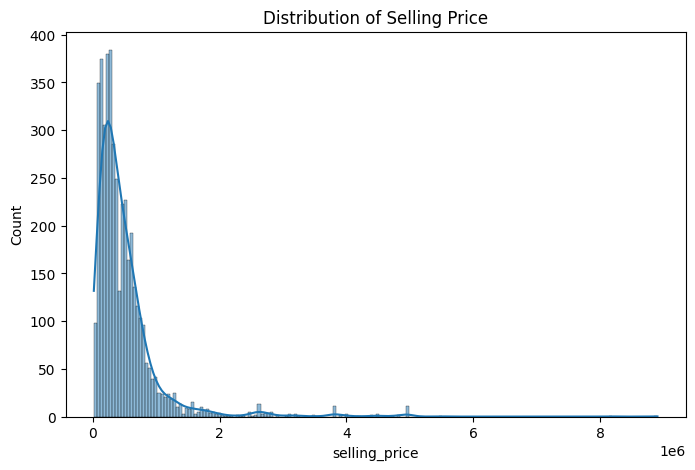

In [52]:
plt.figure(figsize=(8, 5))
sns.histplot(car_dataset["selling_price"], kde=True)
plt.title("Distribution of Selling Price")
plt.show()

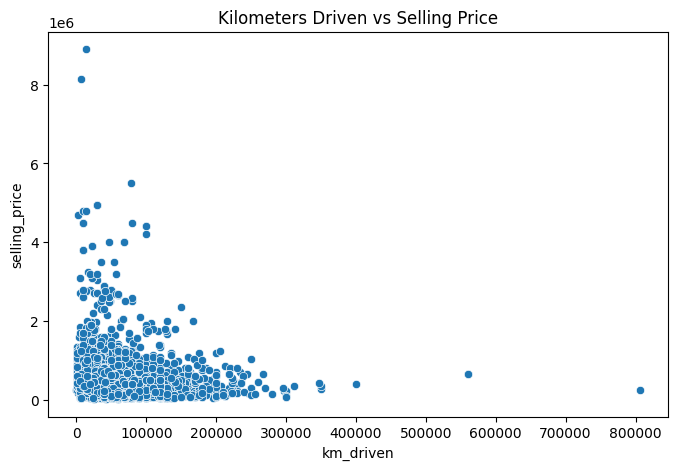

In [53]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="km_driven", y="selling_price", data=car_dataset)
plt.title("Kilometers Driven vs Selling Price")
plt.show()

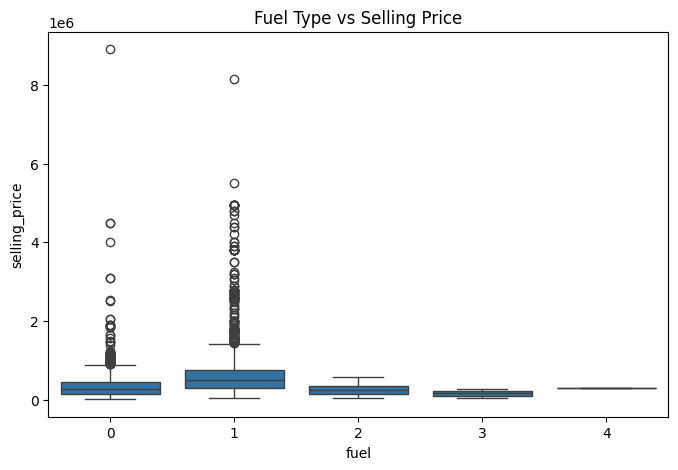

In [54]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="fuel", y="selling_price", data=car_dataset)
plt.title("Fuel Type vs Selling Price")
plt.show()

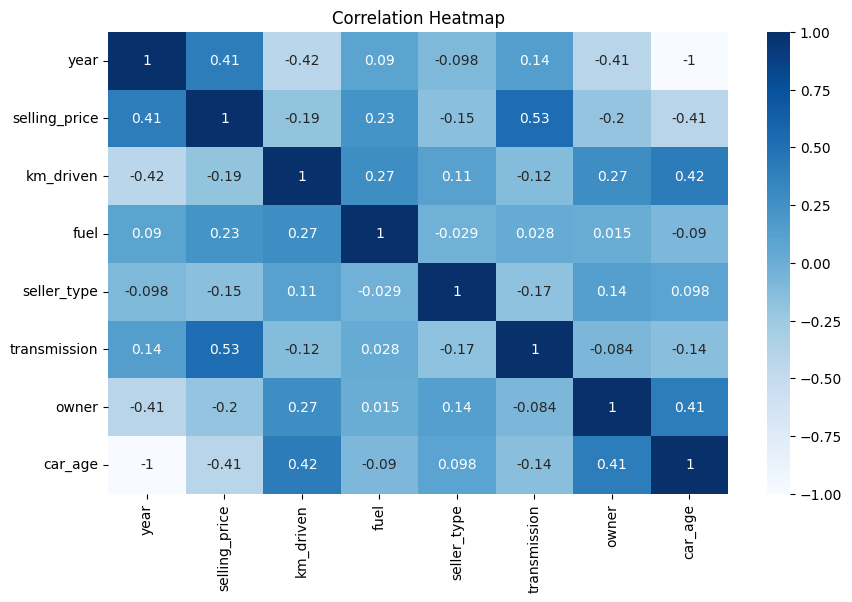

In [55]:
plt.figure(figsize=(10, 6))
sns.heatmap(car_dataset.drop(columns=["name"]).corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

Splitting Training and test data

In [56]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.1,random_state=2)

Model Training

1.  Linear Regression



In [57]:
lin_reg_model = LinearRegression()

In [58]:
lin_reg_model.fit(X_train,Y_train)

LinearRegression()

2. Lasso Regression

In [59]:
lass_reg_model = Lasso()

In [60]:
lass_reg_model.fit(X_train,Y_train)

Lasso()

Model Evaluation


In [61]:
def evaluate_model(model, X_train, X_test, Y_train, Y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    print("Training R2:", r2_score(Y_train, train_pred))
    print("Testing R2:", r2_score(Y_test, test_pred))
    print("MAE:", mean_absolute_error(Y_test, test_pred))
    print("RMSE:", np.sqrt(mean_squared_error(Y_test, test_pred)))

In [62]:
evaluate_model(lin_reg_model, X_train, X_test, Y_train, Y_test)

Training R2: 0.4276361285018674
Testing R2: 0.502799935375341
MAE: 223675.400394783
RMSE: 409261.4404464818


In [63]:
evaluate_model(lass_reg_model, X_train, X_test, Y_train, Y_test)

Training R2: 0.42763612844686816
Testing R2: 0.5027994839513695
MAE: 223675.08301748175
RMSE: 409261.62623726914


In [64]:
rf_model = RandomForestRegressor(random_state=2)
rf_model.fit(X_train, Y_train)

evaluate_model(rf_model, X_train, X_test, Y_train, Y_test)

Training R2: 0.9149834849404495
Testing R2: 0.6966951479981321
MAE: 152414.10958806716
RMSE: 319650.15486184595


In [65]:
models = {
    "Linear Regression": lin_reg_model,
    "Lasso Regression": lass_reg_model,
    "Random Forest": rf_model
}

results = []

for name, model in models.items():
    pred = model.predict(X_test)
    results.append({
        "Model": name,
        "R2 Score": r2_score(Y_test, pred),
        "MAE": mean_absolute_error(Y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(Y_test, pred))
    })

results_df = pd.DataFrame(results)
results_df

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.502800,223675.400395,409261.440446
1,Lasso Regression,0.502799,223675.083017,409261.626237
2,Random Forest,0.696695,152414.109588,319650.154862


In [66]:
input_data = (X.iloc[5])

input_data_as_numpy = np.asarray(input_data)

input_data_reshaped = input_data_as_numpy.reshape(1,-1)

prediction = rf_model.predict(input_data_reshaped)

print(prediction)

[136900.]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


## Conclusion

In this project, a used car price prediction model was built using machine learning.

- The dataset contained 4340 used car records.
- Categorical features such as fuel type, seller type, transmission, and owner type were encoded.
- A new feature, **car_age**, was created from the manufacturing year.
- Linear Regression, Lasso Regression, and Random Forest Regressor were trained and evaluated.
- Linear Regression and Lasso Regression gave moderate performance.
- Random Forest Regressor achieved the best performance with a test R² score of approximately 0.69.
- Therefore, Random Forest was selected as the final model.
- This model can be used in a Streamlit web application for interactive used car price prediction.

In [67]:
import pickle

with open("model.pkl", "wb") as file:
    pickle.dump(rf_model, file)